In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("priyangshumukherjee/mental-health-text-classification-dataset")

print("Path to dataset files:", path)

C:\Users\siawc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\siawc\.cache\kagglehub\datasets\priyangshumukherjee\mental-health-text-classification-dataset\versions\2


In [3]:
# importing dependencies
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer



In [4]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\siawc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\siawc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\siawc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\siawc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
file_path = './health_folder'
os.makedirs(file_path,exist_ok=True)


In [21]:

new_path = os.listdir(path)[0]
paths = os.listdir(path)

featured_path = os.listdir(path)[2]
unbalanced_path = os.listdir(path)[3]


data = pd.read_csv(os.path.join(path,new_path))
data.to_csv(os.path.join(file_path,'mental_health_combined_test.csv'),index=False)

feature_data = pd.read_csv(os.path.join(path,featured_path))
feature_data.to_csv(os.path.join(file_path,'mental_heath_feature_engineered.csv'),index=False)

unbalanced_data = pd.read_csv(os.path.join(path,unbalanced_path))
unbalanced_data.to_csv(os.path.join(file_path,'mental_heath_unbanlanced.csv'))


Performing EDA on Unbalanced data

In [22]:
# loading the datasets
unbalanced_data.head(5)

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


In [9]:
#information about the datasets
unbalanced_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49612 entries, 0 to 49611
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Unique_ID  40012 non-null  float64
 1   text       49612 non-null  object 
 2   status     49612 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.1+ MB


In [10]:
#value counts of the data
unbalanced_data['status'].value_counts()

status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64

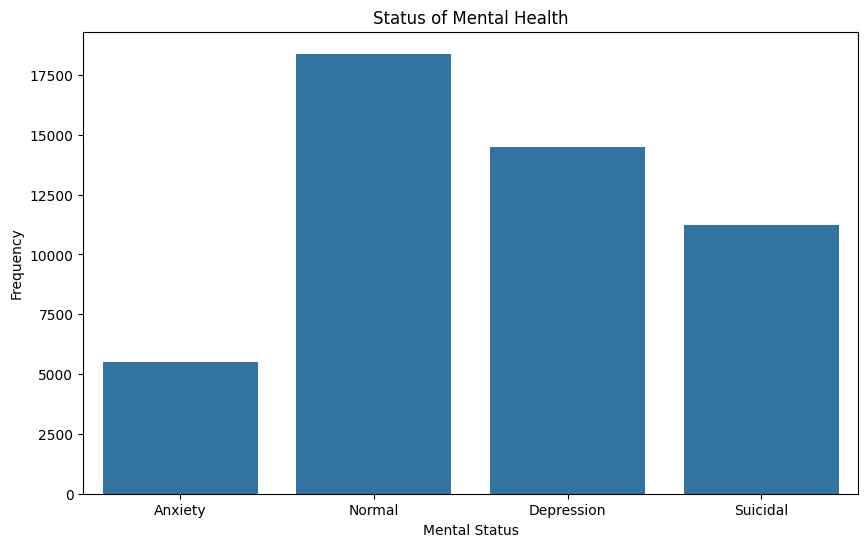

In [11]:
#plotting the graph of the status of mental health
plt.figure(figsize=(10,6))
sns.countplot(x='status',data=unbalanced_data)
plt.title('Status of Mental Health')
plt.xlabel('Mental Status')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 1.0, 'Most Common Words in Suicidal Class')

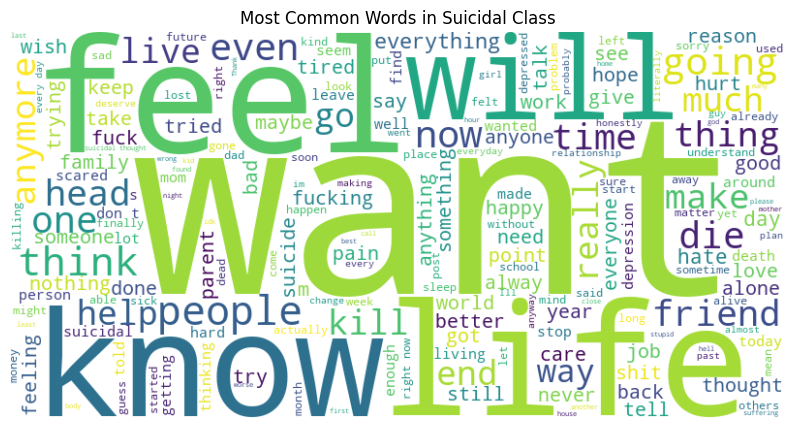

In [12]:
# finding the most common words in the suicidal class using word cloud
suicidal_text = unbalanced_data[unbalanced_data['status'] == 'Suicidal']['text']
suicidal_words = ' '.join(suicidal_text)

wordcloud = WordCloud(width=800, 
                      height=400, 
                      background_color='white').generate(suicidal_words)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Suicidal Class')

Text(0.5, 1.0, 'Most Common Words in Anxiety Class')

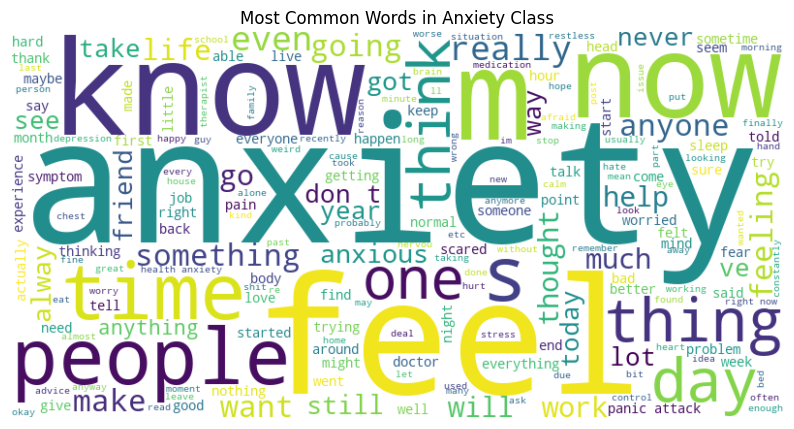

In [13]:
# finding the most common words in the anxiety class using word cloud
anxiety_text = unbalanced_data[unbalanced_data['status'] == 'Anxiety']['text']
anxiety_words = ' '.join(anxiety_text)

wordcloud = WordCloud(width=800, 
                      height=400, 
                      background_color='white').generate(anxiety_words)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Anxiety Class')

Text(0.5, 1.0, 'Most Common Words in Suicidal Class')

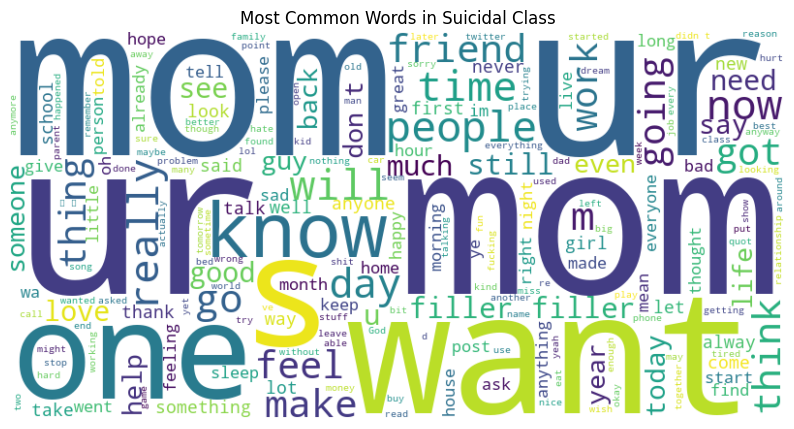

In [14]:
# finding the most common words in the normal class using word cloud
normal_text = unbalanced_data[unbalanced_data['status'] == 'Normal']['text']
normal_words = ' '.join(normal_text)

wordcloud = WordCloud(width=800, 
                      height=400, 
                      background_color='white').generate(normal_words)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Suicidal Class')

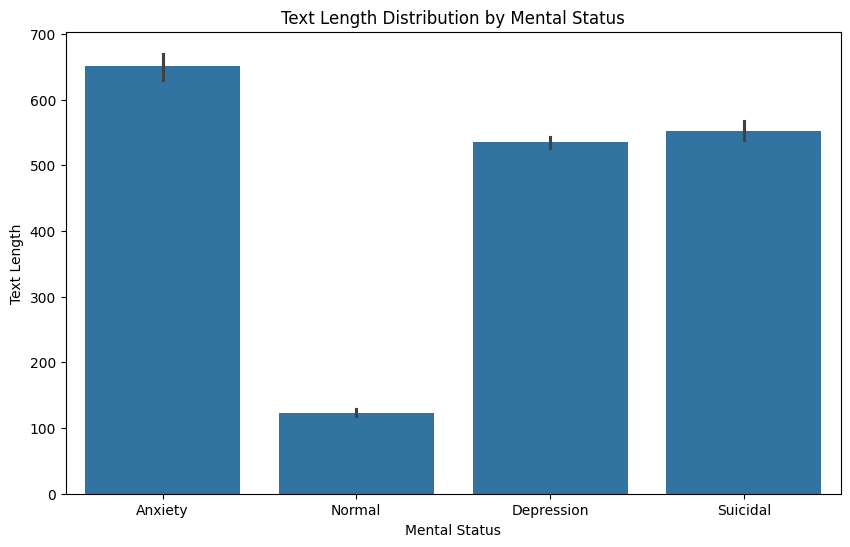

In [15]:
#checking the length of the text in each class
unbalanced_data['text_length'] = unbalanced_data['text'].apply(len)
plt.figure(figsize=(10,6))
sns.barplot(x='status', y='text_length', data=unbalanced_data)
plt.title('Text Length Distribution by Mental Status')
plt.xlabel('Mental Status')
plt.ylabel('Text Length')
plt.show()

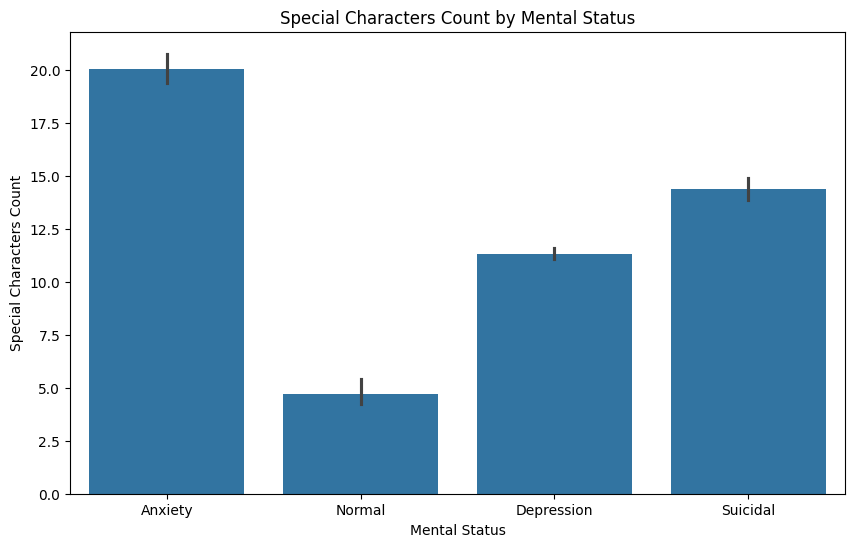

In [16]:
# checking for special characters in the text
unbalanced_data['special_characters'] = unbalanced_data['text'].apply(lambda x: len(re.findall(r'[^\w\s]', x)))
plt.figure(figsize=(10,6))
sns.barplot(x='status', y='special_characters', data=unbalanced_data)
plt.title('Special Characters Count by Mental Status')
plt.xlabel('Mental Status')
plt.ylabel('Special Characters Count')
plt.show()

Preprocessing Stage

In [17]:
def preprocesses_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

unbalanced_data['cleaned_text'] = unbalanced_data['text'].apply(preprocesses_text)
unbalanced_data.head(5)

,Unique_ID,text,status,text_length,special_characters,cleaned_text
0,0.0,oh my gosh,Anxiety,10,0,oh gosh
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety,64,3,trouble sleeping confused mind restless heart ...
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,3,wrong back dear forward doubt stay restless re...
3,3.0,I've shifted my focus to something else but I'...,Anxiety,61,2,ive shifted focus something else im still worried
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety,72,6,im restless restless month boy mean


In [18]:
unbalanced_data.drop(columns=['Unique_ID','text_length','special_characters','text'], inplace=True)
unbalanced_data.head(5)

,status,cleaned_text
0,Anxiety,oh gosh
1,Anxiety,trouble sleeping confused mind restless heart ...
2,Anxiety,wrong back dear forward doubt stay restless re...
3,Anxiety,ive shifted focus something else im still worried
4,Anxiety,im restless restless month boy mean


In [19]:
clean = unbalanced_data.to_csv(os.path.join(file_path,'mental_heath_unbanlanced_cleaned.csv'),index=False)
print("Preprocessing completed and cleaned data saved to 'mental_heath_unbanlanced_cleaned.csv'")

Preprocessing completed and cleaned data saved to 'mental_heath_unbanlanced_cleaned.csv'


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.
